In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer(as_frame=True)

In [4]:
df = data.frame

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [9]:
X = df.drop("target", axis=1)
y = df["target"]

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
X_train = pd.DataFrame(X_train, columns= data.feature_names)
X_test = pd.DataFrame(X_test, columns= data.feature_names)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [15]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

In [16]:
logistic.fit(X_train, y_train)
gbc.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_logistic = logistic.predict(X_test)

print("logistic accuracy_score: ",accuracy_score(y_test, y_pred_logistic))
print("\nlogistic confusion matrix:\n ",confusion_matrix(y_test, y_pred_logistic))
print("\nlogistic classification_report: ",classification_report(y_test, y_pred_logistic))


logistic accuracy_score:  0.9473684210526315

logistic confusion matrix:
  [[34  5]
 [ 1 74]]

logistic classification_report:                precision    recall  f1-score   support

           0       0.97      0.87      0.92        39
           1       0.94      0.99      0.96        75

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [21]:
y_pred_gbc = gbc.predict(X_test)

print("\ngbc accuracy_score: ",accuracy_score(y_test, y_pred_gbc))
print("\ngbc confusion matrix:\n ",confusion_matrix(y_test, y_pred_gbc))
print("\ngbc classification_report: ",classification_report(y_test, y_pred_gbc))


gbc accuracy_score:  0.956140350877193

gbc confusion matrix:
  [[35  4]
 [ 1 74]]

gbc classification_report:                precision    recall  f1-score   support

           0       0.97      0.90      0.93        39
           1       0.95      0.99      0.97        75

    accuracy                           0.96       114
   macro avg       0.96      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



In [23]:
from sklearn.decomposition import PCA

In [37]:
pca = PCA(n_components=4)

In [38]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [39]:
X_train_pca = pd.DataFrame(X_train_pca, columns= ["PCA1", "PCA2","PCA3","PCA4"])
X_test_pca = pd.DataFrame(X_test_pca, columns= ["PCA1", "PCA2","PCA3","PCA4"])

In [40]:
X_train_pca

,PCA1,PCA2,PCA3,PCA4
0,3.622038,-1.868782,-1.738668,-0.454022
1,0.241861,3.448389,-0.016472,1.425944
2,3.972230,0.810955,-1.015291,-0.077998
3,-2.904087,0.248732,-1.320203,-1.778156
4,-1.366459,0.862839,3.082906,-1.319055
...,...,...,...,...
450,3.118982,-1.579959,0.067878,-0.491888
451,1.124494,0.262305,-3.879882,0.669467
452,3.939327,-0.285650,1.374226,-0.710169
453,-2.366661,-1.046686,-1.023462,-1.358265


In [41]:
logistic = LogisticRegression()
gbc = GradientBoostingClassifier()

logistic.fit(X_train_pca, y_train)
gbc.fit(X_train_pca, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [42]:
print("logistic regression")

y_pred_logistic = logistic.predict(X_test_pca)
print(accuracy_score(y_test, y_pred_logistic))
print(confusion_matrix(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))

print("-------------------")
print("gradient boosting classifier")

y_pred_gbc = gbc.predict(X_test_pca)
print(accuracy_score(y_test, y_pred_gbc))
print(confusion_matrix(y_test, y_pred_gbc))
print(classification_report(y_test, y_pred_gbc))

logistic regression
0.9298245614035088
[[34  5]
 [ 3 72]]
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        39
           1       0.94      0.96      0.95        75

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

-------------------
gradient boosting classifier
0.9122807017543859
[[34  5]
 [ 5 70]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        39
           1       0.93      0.93      0.93        75

    accuracy                           0.91       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114



In [44]:
X = df.drop("target", axis=1)

In [45]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [46]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X)

In [49]:
X = pd.DataFrame(X_train_pca, columns= ["PCA1", "PCA2"])

<Axes: xlabel='PCA1', ylabel='PCA2'>

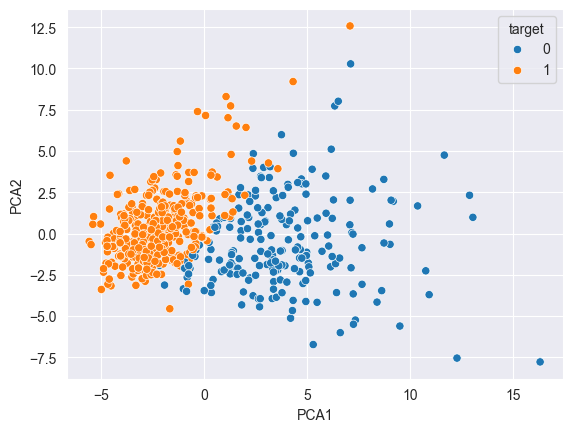

In [51]:
sns.scatterplot(data=X,x="PCA1", y="PCA2", hue=df["target"])